# 1. Get CIFAR-10

Download from URL

In [ ]:
import torchvision
from torchvision.datasets.utils import download_url
import tarfile
import os

# download dataset saved to current folder
dataset_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz'
download_url(dataset_url, '.')

# extract tar file
with tarfile.open('./cifar-10-python.tar.gz') as file:
    file.extractall(path='./data')

data_dir = './data/cifar-10-batches-py'
# see what in the folder dataset
print(os.listdir(data_dir))

['batches.meta', 'readme.html', 'data_batch_1', 'data_batch_4', 'data_batch_3', 'data_batch_2', 'test_batch', 'data_batch_5']


Merge all the batches into a single dataset

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
X_train shape: (50000, 3072)
y_train shape: (50000,)
X_test shape: (10000, 3072)
y_test shape: (10000,)


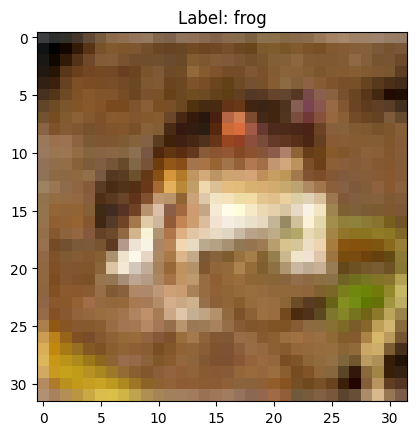

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def load_batches(batch):
  with open(batch, 'rb') as f:
    dict = pickle.load(f, encoding = 'bytes')
    data = dict[b'data']
    labels = dict[b'labels']
    return data, labels

# combine all training batches
X_train = []
y_train = []

for i in range(1, 6):
  batch = os.path.join(data_dir, f'data_batch_{i}')
  data, labels = load_batches(batch)
  X_train.append(data)
  y_train.append(labels)

X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# read test batch
X_test, y_test = load_batches(os.path.join(data_dir, 'test_batch'))
X_test = np.array(X_test)
y_test = np.array(y_test)

# read list of 10 class names
with open(os.path.join(data_dir, 'batches.meta'), 'rb') as f:
  meta = pickle.load(f, encoding='utf-8')
  label_names = meta['label_names']

print(label_names)

# show an example image
images, label = X_train[0], y_train[0]
images = images.reshape(3, 32, 32)
images = images.transpose(1, 2, 0)
plt.title(f'Label: {label_names[label]}')
plt.imshow(images)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# 2. Data preparation

In [ ]:
import torch
from torchvision.transforms import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [ ]:
# reshape images
X_train = X_train.reshape(-1, 3, 32, 32)
X_test = X_test.reshape(-1, 3, 32, 32)

# split validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size = 0.9, random_state = 42)

# normalize data
# define mean and std for CIFAR-10 normalization
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# define training transform
train_transform = transforms.Compose([
  transforms.ToPILImage(),# convert to PIL Image
  transforms.RandomHorizontalFlip(),# randomly flip the image
  transforms.RandomCrop(32, padding=4),# randomly crop a 32x32 patch after padding 4 pixels on each side
  transforms.ToTensor(),# convert the PIL image to tensor and scale pixel values to [0, 1]
  transforms.Normalize(mean, std),# normalize the tensor using the dataset's mean and std
])

# define valid and test transform
test_transform = transforms.Compose([
  transforms.ToPILImage(),# convert to PIL Image
  transforms.ToTensor(),# convert the PIL image to tensor and scale pixel values to [0, 1]
  transforms.Normalize(mean, std),# normalize the tensor using the dataset's mean and std
])

# custom Dataset class
class CIFARDataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels
    self.transform = transform

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, idx):
    img = self.images[idx].transpose(1, 2, 0)  # convert from (C, H, W) to (H, W, C)
    if self.transform:
      img = self.transform(img)
    label = self.labels[idx]
    return img, label

# create Dataset
train_dataset = CIFARDataset(X_train, y_train, transform = train_transform)
val_dataset = CIFARDataset(X_val, y_val, transform = test_transform)
test_dataset = CIFARDataset(X_test, y_test, transform = test_transform)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (45000, 3, 32, 32)
y_train shape: (45000,)
X_val shape: (5000, 3, 32, 32)
y_val shape: (5000,)
X_test shape: (10000, 3, 32, 32)
y_test shape: (10000,)


# 3. Create model, loss function and optimizer

In [ ]:
from torch import nn
import torch.optim as optim

MLP model

In [ ]:
def create_MLP_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # flat data -> 1D
    nn.Flatten(),

    # layer 1
    nn.Linear(3072, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 2
    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(dropout_rate),

    # layer 3 - output layer
    nn.Linear(256, 10)
  )
  return model

CNN model

In [ ]:
def create_CNN_model(dropout_rate = 0.3):
  model = nn.Sequential(
    # CNN-1
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 32 x 16 x 16

    # CNN-2
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 64 x 8 x 8

    # CNN-3
    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), # output: 128 x 4 x 4

    nn.Flatten(),

    # Dense layer
    nn.Linear(128*4*4, 1024),
    nn.ReLU(),
    nn.Linear(1024, 512),
    nn.ReLU(),

    nn.Dropout(dropout_rate),

    # output layer
    nn.Linear(512, 10)
  )
  return model

Loss function and optimizer

In [ ]:
MLP_model = create_MLP_model()
CNN_model = create_CNN_model()

criterion = nn.CrossEntropyLoss()
MLP_optimizer = torch.optim.Adam(MLP_model.parameters(), lr = 0.001)
CNN_optimizer = torch.optim.Adam(CNN_model.parameters(), lr = 0.001)

# 4. Training model

In [ ]:
def train_model(model, train_dataset, val_dataset, criterion, optimizer, batch_size = 128, num_epochs = 10):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True)
  val_loader = DataLoader(val_dataset, batch_size = batch_size * 2, shuffle = False)

  # dict containing 'accuracy', 'val_accuracy', 'loss', 'val_loss' per epoch.
  history = {'train_accuracy': [], 'val_accuracy': [], 'train_loss': [], 'val_loss': []}
  for epoch in range(num_epochs):
    # training loop
    model.train()  # set model to train mode
    train_loss = 0
    train_correct = 0
    train_total = 0

    # loop through batches
    for X_batch, y_batch in train_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # 1. forward pass
      y_pred = model(X_batch)

      # 2. calculate loss
      loss = criterion(y_pred, y_batch)
      train_loss += loss.item()  # accumulate loss

      # 3. optimizer zero grad
      optimizer.zero_grad()

      # 4. backpropagation
      loss.backward()

      # 5. optimizer step
      optimizer.step()

      # calculate accuracy
      preds = torch.argmax(y_pred, dim=1)
      train_correct += (preds == y_batch).sum().item()
      train_total += y_batch.size(0)

    # validation loop
    model.eval()  # set model to eval mode
    val_loss = 0
    val_correct = 0
    val_total = 0

    # no need to calculate gradients
    with torch.inference_mode():
      # loop through batches
      for X_batch, y_batch in val_loader:
        # batch to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # forward pass
        y_pred = model(X_batch)

        # calculate loss
        loss = criterion(y_pred, y_batch)
        val_loss += loss.item()

        # calculate accuracy
        preds = torch.argmax(y_pred, dim=1)
        val_correct += (preds == y_batch).sum().item()
        val_total += y_batch.size(0)

    train_accuracy = train_correct / train_total
    val_accuracy = val_correct / val_total
    train_loss = train_loss / len(train_loader)
    val_loss = val_loss / len(val_loader)

    history['train_accuracy'].append(train_accuracy)
    history['val_accuracy'].append(val_accuracy)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    # print loss and accuracy every epoch
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
          f"Val Loss: {val_loss:.4f}, Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}")
  return history

# 5. Inference

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Evaluate model

In [ ]:
def evaluate_model(model, test_dataset, criterion, batch_size = 128):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  model.eval()  # set model to eval mode
  test_loss = 0
  test_correct = 0
  test_total = 0

  # no need to calculate gradients
  with torch.inference_mode():
    # loop through batches
    for X_batch, y_batch in test_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # forward pass
      y_pred = model(X_batch)

      # calculate loss
      loss = criterion(y_pred, y_batch)
      test_loss += loss.item()

      # calculate accuracy
      preds = torch.argmax(y_pred, dim=1)
      test_correct += (preds == y_batch).sum().item()
      test_total += y_batch.size(0)

  test_loss = test_loss / len(test_loader)
  test_accuracy = test_correct / test_total
  return test_loss, test_accuracy

Plot learning curve

In [ ]:
def plot_curve(history):
  epochs = range(1, len(history["train_accuracy"]) + 1)

  plt.figure(figsize = (12, 5))

  # accuracy plot
  plt.subplot(1, 2, 1)
  plt.plot(epochs, history["train_accuracy"], label = "Train Accuracy")
  plt.plot(epochs, history["val_accuracy"], label = "Validation Accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.title("Accuracy Curve")
  plt.legend()

  # loss plot
  plt.subplot(1, 2, 2)
  plt.plot(epochs, history["train_loss"], label = "Train Loss")
  plt.plot(epochs, history["val_loss"], label = "Validation Loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.title("Loss Curve")
  plt.legend()

  plt.show()

Plot confusion matrix

In [ ]:
def plot_matrix(model, test_dataset, batch_size = 128):
  # check available device
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model = model.to(device)

  # create dataloader
  test_loader = DataLoader(test_dataset, batch_size = batch_size)

  model.eval() # set model to eval mode
  y_true = []
  y_pred = []

  with torch.inference_mode():
    for X_batch, y_batch in test_loader:
      # batch to device
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      # pred X_batch with model
      preds = model(X_batch).argmax(dim = 1)

      # calculate
      y_true.extend(y_batch.cpu().numpy()) # true labels
      y_pred.extend(preds.cpu().numpy()) # predicted labels

  # compute confusion matrix
  cm = confusion_matrix(y_true, y_pred)

  # display the confusion matrix using matplotlib
  disp = ConfusionMatrixDisplay(confusion_matrix = cm)
  disp.plot(cmap = plt.cm.Blues)
  plt.title("Confusion Matrix")
  plt.show()

# Compare MLP model and CNN model

In [ ]:
history = train_model(MLP_model, train_dataset, val_dataset, criterion, MLP_optimizer, batch_size = 128, num_epochs = 30)
plot_curve(history)
test_loss, test_acc = evaluate_model(MLP_model, test_dataset, criterion, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
plot_matrix(MLP_model, test_dataset)

torch.save(MLP_model.state_dict(), 'MLP_model.pth')

Epoch 1/30, Train Loss: 1.8630, Val Loss: 1.6444, Train Accuracy: 0.3206, Val Accuracy: 0.4020
Epoch 2/30, Train Loss: 1.6996, Val Loss: 1.5564, Train Accuracy: 0.3865, Val Accuracy: 0.4450
Epoch 3/30, Train Loss: 1.6489, Val Loss: 1.5198, Train Accuracy: 0.4052, Val Accuracy: 0.4574


In [ ]:
history = train_model(CNN_model, train_dataset, val_dataset, criterion, CNN_optimizer, batch_size = 128, num_epochs = 16)
plot_curve(history)
test_loss, test_acc = evaluate_model(CNN_model, test_dataset, criterion, batch_size = 128)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")
plot_matrix(CNN_model, test_dataset)

torch.save(CNN_model.state_dict(), 'CNN_model.pth')